In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
np.random.seed(42)

n = 1500

data = pd.DataFrame({
    'ApplicantID': range(1001, 1001+n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Age': np.random.randint(21, 60, n),
    'MonthlyIncome': np.random.randint(15000, 150000, n),
    'LoanAmount': np.random.randint(50000, 1500000, n),
    'CreditScore': np.random.randint(300, 900, n),
    'EmploymentStatus': np.random.choice(
        ['Employed', 'Self-Employed', 'Unemployed'],
        n,
        p=[0.6,0.25,0.15]
    ),
    'ExistingLoans': np.random.randint(0,5,n),
    'LoanTerm': np.random.choice([12,24,36,48,60], n),
    'PropertyArea': np.random.choice(
        ['Urban','Semi-Urban','Rural'],
        n
    )
})

approval = []

for i in range(n):

    score = 0

    if data.loc[i,'MonthlyIncome'] > 50000:
        score += 2

    if data.loc[i,'CreditScore'] > 650:
        score += 3

    if data.loc[i,'EmploymentStatus'] != 'Unemployed':
        score += 2

    if data.loc[i,'ExistingLoans'] <= 2:
        score += 1

    if data.loc[i,'LoanAmount'] < data.loc[i,'MonthlyIncome'] * 25:
        score += 2

    approval.append(1 if score >= 6 else 0)

data['LoanApproved'] = approval

data.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,1001,Male,26,99045,740955,899,Employed,1,36,Rural,1
1,1002,Female,26,131859,80257,680,Employed,4,48,Semi-Urban,1
2,1003,Male,23,18471,457427,628,Employed,1,36,Urban,0
3,1004,Male,27,135312,932421,778,Employed,3,48,Rural,1
4,1005,Male,28,61850,972736,314,Employed,1,36,Semi-Urban,1


In [3]:
data.to_csv("loan_dataset.csv", index=False)

print("Dataset Created Successfully")
print(data.shape)

Dataset Created Successfully
(1500, 11)


In [4]:
for col in ['Gender','CreditScore']:
    data.loc[data.sample(frac=0.02).index,col] = np.nan

data.isnull().sum()

,0
ApplicantID,0
Gender,30
Age,0
MonthlyIncome,0
LoanAmount,0
CreditScore,30
EmploymentStatus,0
ExistingLoans,0
LoanTerm,0
PropertyArea,0


Data Cleaning

In [6]:
data.drop_duplicates(inplace=True)

data['Gender'].fillna(
    data['Gender'].mode()[0],
    inplace=True
)

data['CreditScore'].fillna(
    data['CreditScore'].median(),
    inplace=True
)

print("Missing Values After Cleaning")
print(data.isnull().sum())

Missing Values After Cleaning
ApplicantID         0
Gender              0
Age                 0
MonthlyIncome       0
LoanAmount          0
CreditScore         0
EmploymentStatus    0
ExistingLoans       0
LoanTerm            0
PropertyArea        0
LoanApproved        0
dtype: int64


Basic Information

In [7]:
print(data.info())

print("\n")

print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ApplicantID       1500 non-null   int64  
 1   Gender            1500 non-null   object 
 2   Age               1500 non-null   int64  
 3   MonthlyIncome     1500 non-null   int64  
 4   LoanAmount        1500 non-null   int64  
 5   CreditScore       1500 non-null   float64
 6   EmploymentStatus  1500 non-null   object 
 7   ExistingLoans     1500 non-null   int64  
 8   LoanTerm          1500 non-null   int64  
 9   PropertyArea      1500 non-null   object 
 10  LoanApproved      1500 non-null   int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 129.0+ KB
None


       ApplicantID          Age  MonthlyIncome    LoanAmount  CreditScore  \
count  1500.000000  1500.000000    1500.000000  1.500000e+03   1500.00000   
mean   1750.500000    40.250000   81471.986667  7.639251e

Approval Distribution

In [8]:
data['LoanApproved'].value_counts()

,count
LoanApproved,
1,1128
0,372


 Employment Status vs Approval

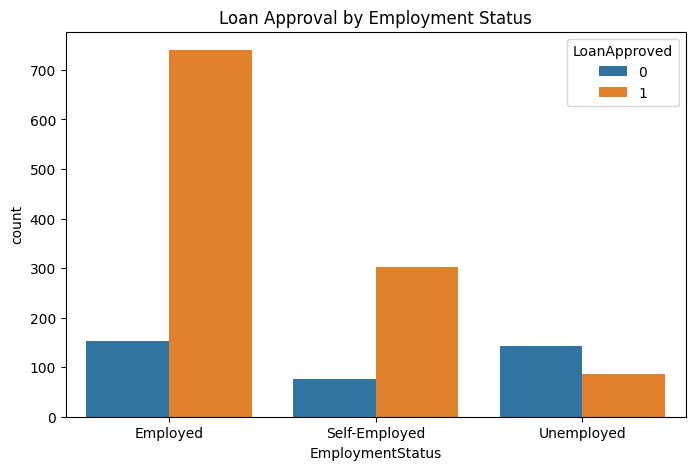

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='EmploymentStatus',
    hue='LoanApproved',
    data=data
)

plt.title("Loan Approval by Employment Status")
plt.show()

Correlation Heatmap

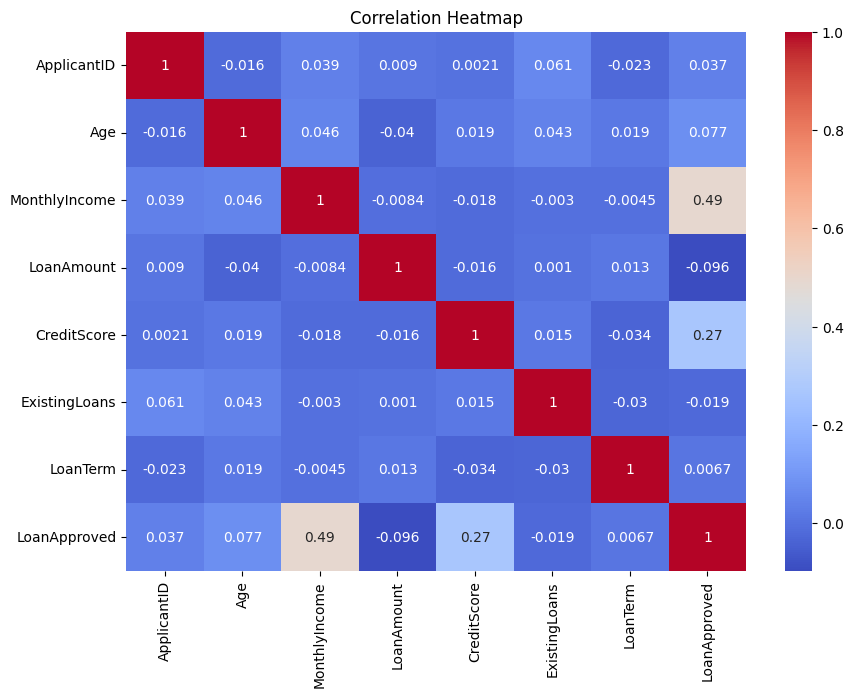

In [10]:
numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Income vs Loan Amount

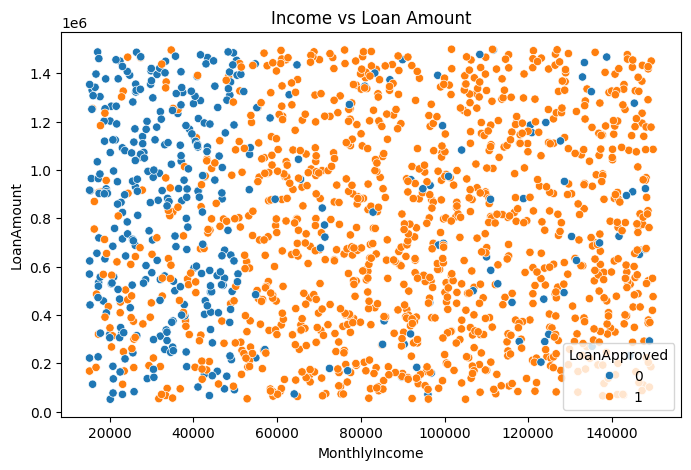

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='MonthlyIncome',
    y='LoanAmount',
    hue='LoanApproved',
    data=data
)

plt.title("Income vs Loan Amount")
plt.show()

Pie Chart

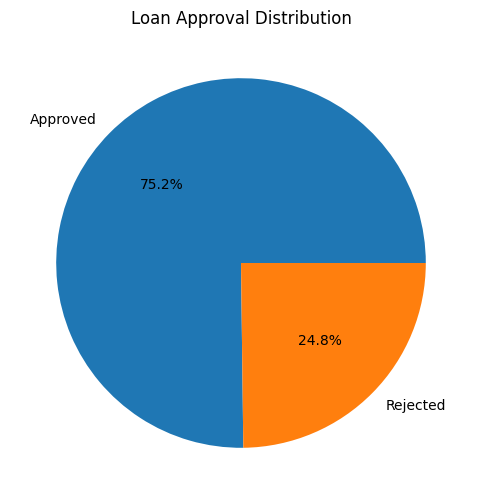

In [12]:
approved = data['LoanApproved'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    approved,
    labels=['Approved','Rejected'],
    autopct='%1.1f%%'
)

plt.title("Loan Approval Distribution")

plt.show()

Encode Categorical Features

In [13]:
le = LabelEncoder()

data['Gender'] = le.fit_transform(data['Gender'])

data['EmploymentStatus'] = le.fit_transform(
    data['EmploymentStatus']
)

data['PropertyArea'] = le.fit_transform(
    data['PropertyArea']
)

data.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,1001,1,26,99045,740955,899.0,0,1,36,0,1
1,1002,0,26,131859,80257,680.0,0,4,48,1,1
2,1003,1,23,18471,457427,628.0,0,1,36,2,0
3,1004,1,27,135312,932421,778.0,0,3,48,0,1
4,1005,1,28,61850,972736,314.0,0,1,36,1,1


Feature Selection

In [14]:
X = data.drop(
    ['ApplicantID','LoanApproved'],
    axis=1
)

y = data['LoanApproved']

print(X.head())

   Gender  Age  MonthlyIncome  LoanAmount  CreditScore  EmploymentStatus  \
0       1   26          99045      740955        899.0                 0   
1       0   26         131859       80257        680.0                 0   
2       1   23          18471      457427        628.0                 0   
3       1   27         135312      932421        778.0                 0   
4       1   28          61850      972736        314.0                 0   

   ExistingLoans  LoanTerm  PropertyArea  
0              1        36             0  
1              4        48             1  
2              1        36             2  
3              3        48             0  
4              1        36             1  


Feature Scaling

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1200, 9)
(300, 9)


Train Model

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


Predictions

In [18]:

y_pred = model.predict(X_test)

Evaluation Metrics

In [19]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

print("Accuracy :",accuracy)

print("Precision :",precision)

print("Recall :",recall)

print("F1 Score :",f1)

Accuracy : 0.9966666666666667
Precision : 0.9956896551724138
Recall : 1.0
F1 Score : 0.9978401727861771


Classification Report

In [20]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        69
           1       1.00      1.00      1.00       231

    accuracy                           1.00       300
   macro avg       1.00      0.99      1.00       300
weighted avg       1.00      1.00      1.00       300



Confusion Matrix

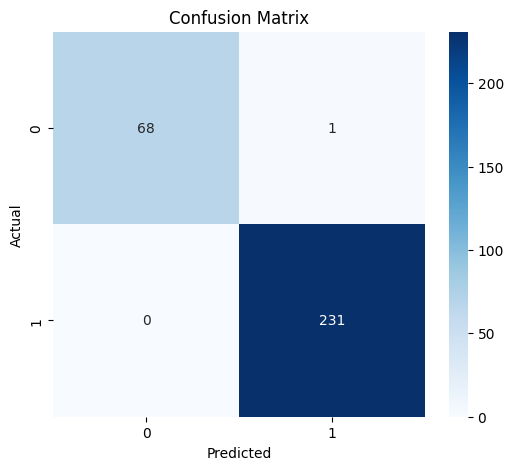

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Interactive Loan Prediction System

In [24]:
print("\nLOAN APPROVAL PREDICTION SYSTEM\n")

try:

    gender = input("Gender (Male/Female): ")

    age = int(input("Age: "))

    income = float(input("Monthly Income: "))

    loan_amount = float(input("Loan Amount: "))

    credit_score = int(input("Credit Score: "))

    employment = input(
        "Employment Status (Employed/Self-Employed/Unemployed): "
    )

    existing_loans = int(
        input("Existing Loans: ")
    )

    loan_term = int(
        input("Loan Term: ")
    )

    property_area = input(
        "Property Area (Urban/Semi-Urban/Rural): "
    )

    gender_map = {
        'Male':1,
        'Female':0
    }

    employment_map = {
        'Employed':0,
        'Self-Employed':1,
        'Unemployed':2
    }

    property_map = {
        'Rural':0,
        'Semi-Urban':1,
        'Urban':2
    }

    user_data = pd.DataFrame([[
        gender_map[gender],
        age,
        income,
        loan_amount,
        credit_score,
        employment_map[employment],
        existing_loans,
        loan_term,
        property_map[property_area]
    ]],
    columns=X.columns)

    user_scaled = scaler.transform(user_data)

    prediction = model.predict(user_scaled)

    if prediction[0] == 1:
        print("\nLoan Approved")
    else:
        print("\nLoan Rejected")

except Exception as e:
    print("Invalid Input:", e)


LOAN APPROVAL PREDICTION SYSTEM

Gender (Male/Female): Male
Age: 25
Monthly Income: 14000
Loan Amount: 1400000
Credit Score: 500
Employment Status (Employed/Self-Employed/Unemployed): Employed
Existing Loans: 3
Loan Term: 45
Property Area (Urban/Semi-Urban/Rural): Rural

Loan Rejected
